In [33]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/retrospective_t2e/')

from gls import datasets

import pandas as pd
import numpy as np

def load_aimhigh_trial_data():

  feature_list = {
    # demographic data
    'patient.sas7bdat' : ['Age', 'Sex', 'ethn', 'Race', 'HxDiab', 'Smoke', 'MetabSyn', 'BMI', 'SysBP', 'DiasBP', 
                        'LDL_C_Base', 'HDL_C_Base', 'Trig_Base', 'Glucose_Base', 'Lpa', 'RandAssi']
  }
  outcomes, features = datasets._load_generic_biolincc_dataset('patient.sas7bdat', 
                                                                   'ETPrimaryA6', 'VSDthA6',
                                                                   features=feature_list, 
                                                                   id_col='PatientKey',
                                                                   location='datasets/AIMHIGH/')

  # Convert Censoring Indicator to Binary
  # ie. 1 = Event, 0 = Censored
  outcomes.event = outcomes.event == 1.0 
  
  NaNindex = pd.isna(outcomes.time)
  outcomes = outcomes.loc[~NaNindex]
  features = features.loc[~NaNindex]

  return outcomes, features

In [34]:
import pandas as pd
import torch
from tqdm import tqdm
from examples.cmhe_demo_utils import * 

In [35]:
# Load the synthetic dataset
outcomes, features = load_aimhigh_trial_data()

# Let's take a look at take the dataset
features.head(5)

(4273, 16)


,DiasBP,LDL_C_Base,HxDiab,ethn,Race,Smoke,Age,Sex,BMI,Trig_Base,Glucose_Base,Lpa,RandAssi,HDL_C_Base,SysBP,MetabSyn
PatientKey,,,,,,,,,,,,,,,,
1.0,62.0,75.0,1.0,1.0,5.0,4.0,69.0,1.0,36.3,140.0,111.0,17.4,0.0,33.0,143.0,1.0
2.0,72.0,70.0,0.0,1.0,5.0,1.0,69.0,1.0,30.9,192.0,102.0,50.5,0.0,38.0,116.0,1.0
3.0,58.0,48.0,1.0,1.0,5.0,1.0,58.0,1.0,38.1,252.0,172.0,2.8,1.0,35.0,107.0,1.0
7.0,95.0,69.0,0.0,1.0,5.0,4.0,58.0,1.0,28.7,327.0,106.0,2.8,1.0,30.0,117.0,1.0
9.0,77.0,62.0,0.0,1.0,5.0,4.0,56.0,0.0,39.5,145.0,106.0,54.6,1.0,27.0,108.0,1.0


In [36]:
interventions = features['RandAssi']
interventions

PatientKey
1.0       0.0
2.0       0.0
3.0       1.0
7.0       1.0
9.0       1.0
         ... 
8157.0    1.0
8158.0    1.0
8159.0    1.0
8160.0    1.0
8162.0    1.0
Name: RandAssi, Length: 3414, dtype: float64

In [37]:
from preprocessing import Preprocessor

cat_feats = ['Race', 'Smoke', 'MetabSyn', 'HxDiab', 'Sex', 'ethn']
num_feats = ['Age', 'Lpa', 'SysBP', 'LDL_C_Base', 'BMI', 'Glucose_Base', 'DiasBP', 'Trig_Base', 'HDL_C_Base']

features = Preprocessor().fit_transform(features[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [38]:
features.head()

,Age,Lpa,SysBP,LDL_C_Base,BMI,Glucose_Base,DiasBP,Trig_Base,HDL_C_Base,Race_5.0,Race_8.0,Smoke_2.0,Smoke_3.0,Smoke_4.0,MetabSyn_1.0,MetabSyn_2.0,HxDiab_1.0,Sex_1.0,ethn_2.0
PatientKey,,,,,,,,,,,,,,,,,,,
1.0,0.610827,-0.670381,0.903030,0.038767,0.953478,0.019726,-1.263547,-0.639595,-0.306123,1,0,0,0,1,1,0,1,1,0
2.0,0.610827,-0.294209,-0.752606,-0.178342,-0.060279,-0.379981,-0.241422,0.139126,0.584388,1,0,0,0,0,1,0,0,1,0
3.0,-0.649973,-0.836306,-1.304485,-1.133622,1.291397,2.728851,-1.672397,1.037650,0.050081,1,0,0,0,0,1,0,1,1,0
7.0,-0.649973,-0.836306,-0.691286,-0.221764,-0.473291,-0.202334,2.109466,2.160805,-0.840429,1,0,0,0,1,1,0,0,1,0
9.0,-0.879210,-0.247614,-1.243165,-0.525717,1.554222,-0.202334,0.269641,-0.564718,-1.374735,1,0,0,0,1,1,0,0,0,0


In [39]:
# Hyper-parameters
random_seed = 0
test_size = 0.4

# Split the synthetic data into training and testing data
import numpy as np

np.random.seed(random_seed)
n = features.shape[0] 

test_idx = np.zeros(n).astype('bool')
test_idx[np.random.randint(n, size=int(n*test_size))] = True 

features_tr = features.iloc[~test_idx] 
outcomes_tr = outcomes.iloc[~test_idx]
interventions_tr = interventions[~test_idx]
print(f'Number of training data points: {len(features_tr)}')

features_te = features.iloc[test_idx] 
outcomes_te = outcomes.iloc[test_idx]
interventions_te = interventions[test_idx]
print(f'Number of test data points: {len(features_te)}')

x_tr = features_tr.values.astype('float32')
t_tr = outcomes_tr['time'].values.astype('float32')
e_tr = outcomes_tr['event'].values.astype('float32')
a_tr = interventions_tr.values.astype('float32')

x_te = features_te.values.astype('float32')
t_te = outcomes_te['time'].values.astype('float32')
e_te = outcomes_te['event'].values.astype('float32')
a_te = interventions_te.values.astype('float32')

print('Training Data Statistics:')
print(f'Shape of covariates: {x_tr.shape} | times: {t_tr.shape} | events: {e_tr.shape} | interventions: {a_tr.shape}')

Number of training data points: 2293
Number of test data points: 1121
Training Data Statistics:
Shape of covariates: (2293, 19) | times: (2293,) | events: (2293,) | interventions: (2293,)


In [40]:
# Hyper-parameters to train model
k = 1 # number of underlying base survival phenotypes
g = 2 # number of underlying treatment effect phenotypes.
layers = [] # number of neurons in each hidden layer.

random_seed = 3
iters = 100 # number of training epochs
learning_rate = 0.001
batch_size = 128 
vsize = 0.15 # size of the validation split
patience = 3
optimizer = "Adam"

In [41]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model
model = DeepCoxMixturesHeterogenousEffects(random_seed=7, k=k, g=g, layers=layers)

model = model.fit(x_tr, t_tr, e_tr, a_tr, vsize=vsize, val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

100%|██████████| 100/100 [00:13<00:00,  7.17it/s]


In [42]:
zeta_probs_train = model.predict_latent_phi(x_tr)
zeta_train =  np.argmax(zeta_probs_train, axis=1)
zeta_train

array([0, 1, 0, ..., 0, 0, 1], dtype=int64)

In [43]:
zeta_train.mean()

0.3789795028347143

In [44]:
idx_list_0 = np.where(zeta_train == 0)

In [45]:
idx_list_1 = np.where(zeta_train == 1)

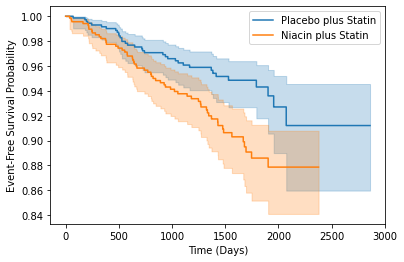

In [46]:
from auton_survival import reporting
import matplotlib.pyplot as plt

# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax = reporting.plot_kaplanmeier(outcomes_tr.iloc[idx_list_0], interventions_tr.iloc[idx_list_0])
h, l = ax.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Placebo plus Statin', 'Niacin plus Statin'], loc="upper right")
plt.show()

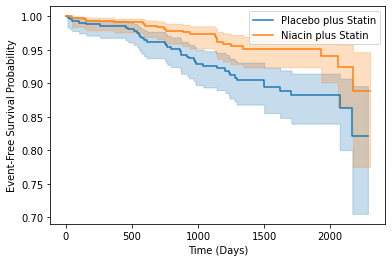

In [47]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax2 = reporting.plot_kaplanmeier(outcomes_tr.iloc[idx_list_1], interventions_tr.iloc[idx_list_1])
h, l = ax2.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Placebo plus Statin', 'Niacin plus Statin'], loc="upper right")
plt.show()

In [48]:
zeta_probs_test = model.predict_latent_phi(x_te)
zeta_test =  np.argmax(zeta_probs_test, axis=1)
zeta_test

array([1, 1, 0, ..., 0, 0, 0], dtype=int64)

In [49]:
zeta_test.mean()

0.40588760035682425

In [50]:
idx_list_0te = np.where(zeta_test == 0)
idx_list_1te = np.where(zeta_test == 1)

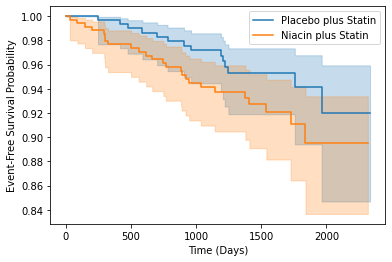

In [51]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax3 = reporting.plot_kaplanmeier(outcomes_te.iloc[idx_list_0te], interventions_te.iloc[idx_list_0te])
h, l = ax3.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Placebo plus Statin', 'Niacin plus Statin'], loc="upper right")
plt.show()

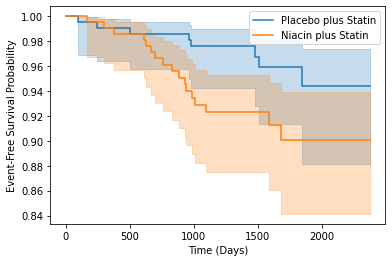

In [52]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax4 = reporting.plot_kaplanmeier(outcomes_te.iloc[idx_list_1te], interventions_te.iloc[idx_list_1te])
h, l = ax4.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Placebo plus Statin', 'Niacin plus Statin'], loc="upper right")
plt.show()